In [ ]:
%run scripts/verify_environment.py

verify_environment()

In [ ]:
from getpass import getpass

admin_rdm_url = 'https://admin.bh.rdm.yzwlab.com/' # 'https://admin.staging.rdm.example.com'
rdm_url = 'https://bh.rdm.yzwlab.com/' # 'https://staging.rdm.example.com'
idp_name_project_limit_1 = None
idp_username_project_limit_1 = None
idp_password_project_limit_1 = None

# 統合管理者用 (manager)
idp_name_integrated_admin = None
idp_username_integrated_admin = None
idp_password_integrated_admin = None

default_result_path = None
close_on_fail = False
transition_timeout = 30000

In [3]:
if idp_name_project_limit_1 is None:
    idp_name_project_limit_1 = input(prompt=f'IdP Name: ')
if idp_username_project_limit_1 is None:
    idp_username_project_limit_1 = input(prompt=f'Username for {idp_name_project_limit_1}')
if idp_password_project_limit_1 is None:
    idp_password_project_limit_1 = getpass(prompt=f'Password for {idp_username_project_limit_1}@{idp_name_project_limit_1}')

if idp_name_integrated_admin is None:
    idp_name_integrated_admin = input(prompt=f'IdP Name for integrated admin: ')
if idp_username_integrated_admin is None:
    idp_username_integrated_admin = input(prompt=f'Username for {idp_name_integrated_admin} (integrated admin)')
if idp_password_integrated_admin is None:
    idp_password_integrated_admin = getpass(prompt=f'Password for {idp_username_integrated_admin}@{idp_name_integrated_admin}')

In [ ]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

# プロジェクト制限数_テンプレート削除

- サブシステム名: プロジェクト制限数
- ページ/アドオン: テンプレート削除
- 機能分類: テンプレート
- シナリオ名: プロジェクト制限数のテンプレート削除
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM, 統合管理者既存ユーザー: GRDM)

In [ ]:
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

## ウェブブラウザの新規プライベートウィンドウで GRDM トップページを表示する

GRDM トップページが表示されること


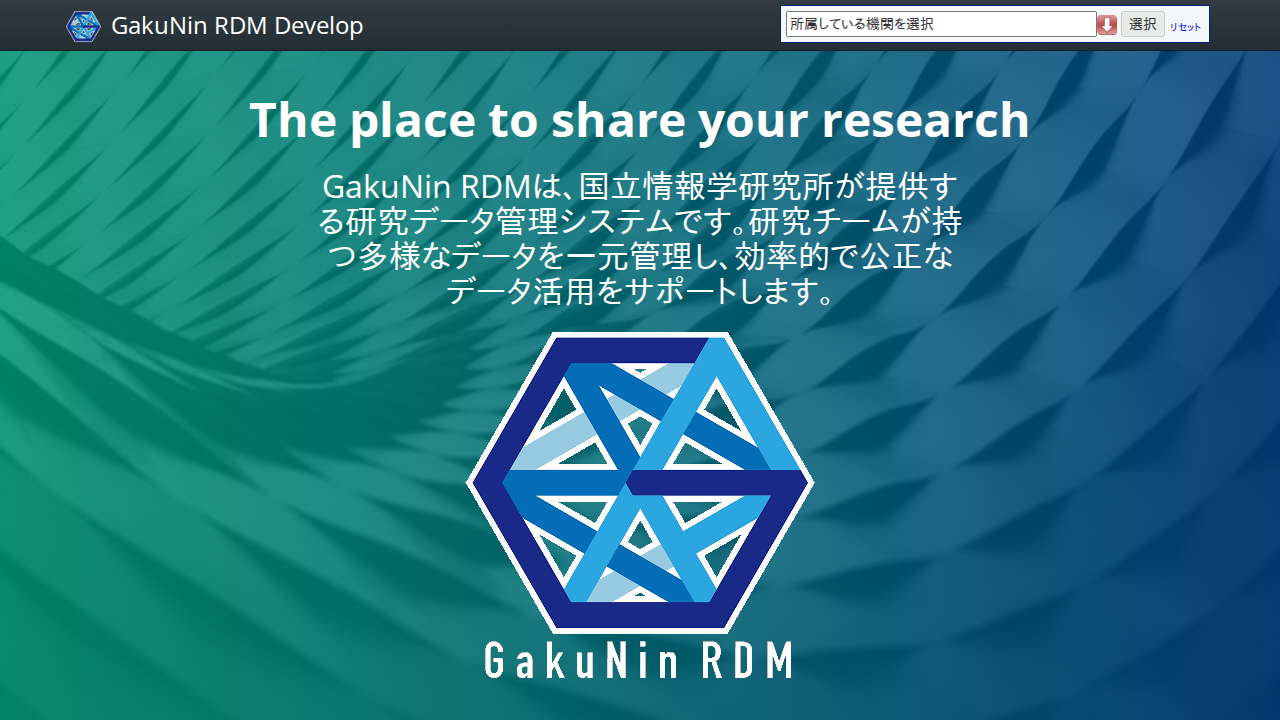

In [6]:
async def _step(page):
    await page.goto(rdm_url)

    # 同意する をクリック
    await page.locator('//button[text() = "同意する"]').click()

    # 同意する が表示されなくなったことを確認
    await expect(page.locator('//button[text() = "同意する"]')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

## RDMIdPを利用し、既存ユーザー1としてログインする

GRDM ダッシュボードが表示されること


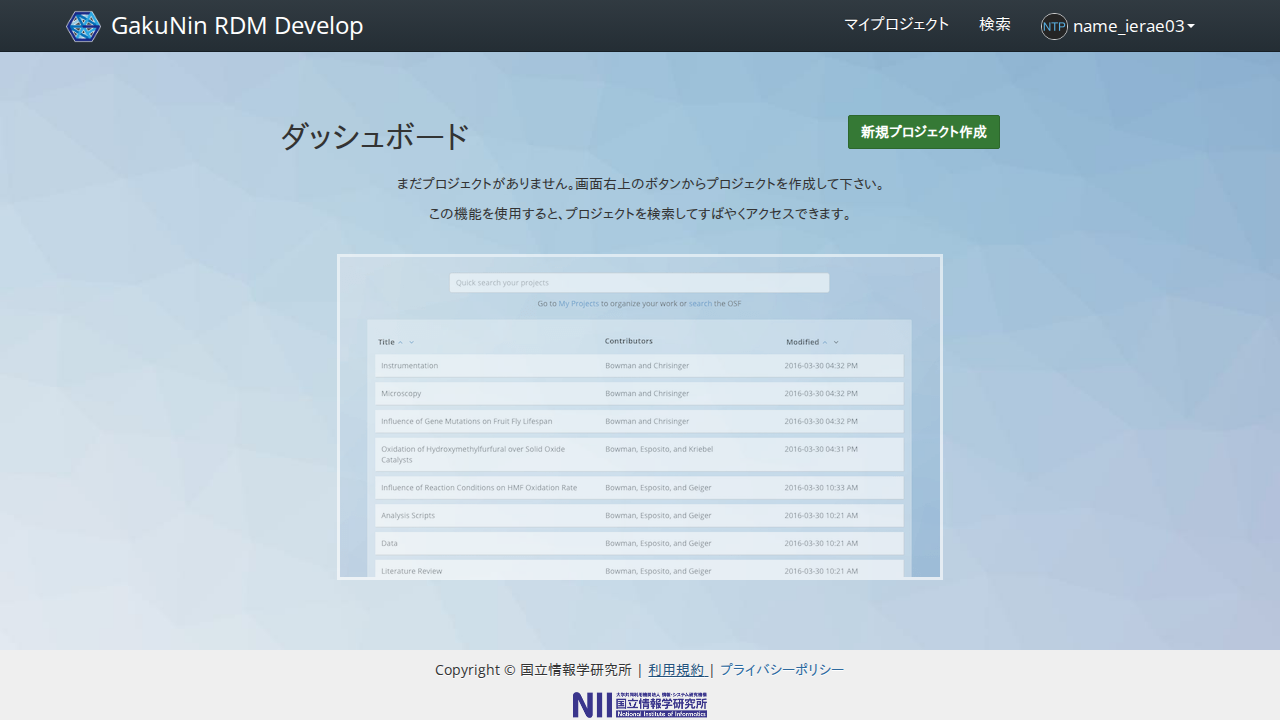

In [7]:
async def _step(page):
    await scripts.grdm.login(
        page, idp_name_project_limit_1, idp_username_project_limit_1, idp_password_project_limit_1, transition_timeout=transition_timeout
    )

    await scripts.grdm.expect_dashboard(page, transition_timeout=transition_timeout)

await run_pw(_step)

## 画面右上のユーザ名をクリックし、「設定」を選択する。

「設定」画面が表示されること


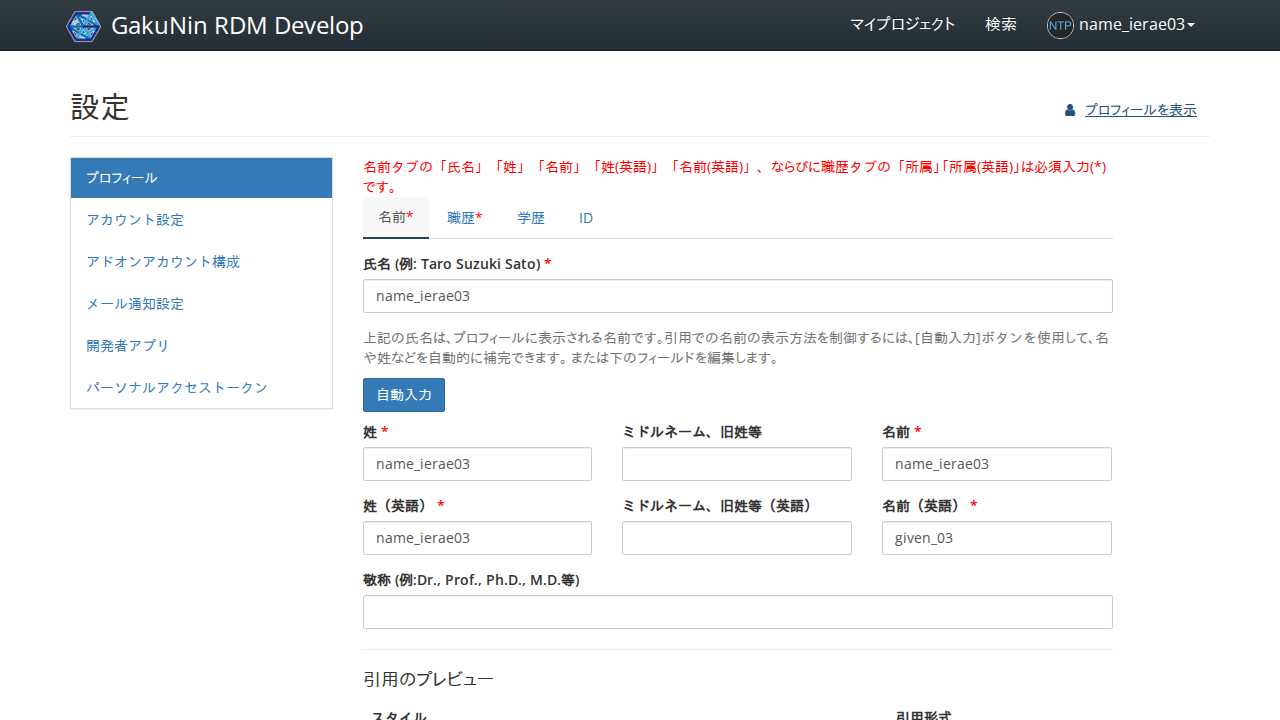

In [9]:
async def _step(page):
    await page.locator(f'//div[@class = "nav-profile-name"]').click()
    await expect(page.locator('//*[@data-analytics-name="Settings"]')).to_be_visible(timeout=transition_timeout)

    await page.locator('//*[@data-analytics-name="Settings"]').click()
    await expect(page.locator('//*[text() = "アカウント設定"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 左のメニューから「アカウント設定」を選択する。

「登録メールアドレス」の「プライマリメール」を確認すること


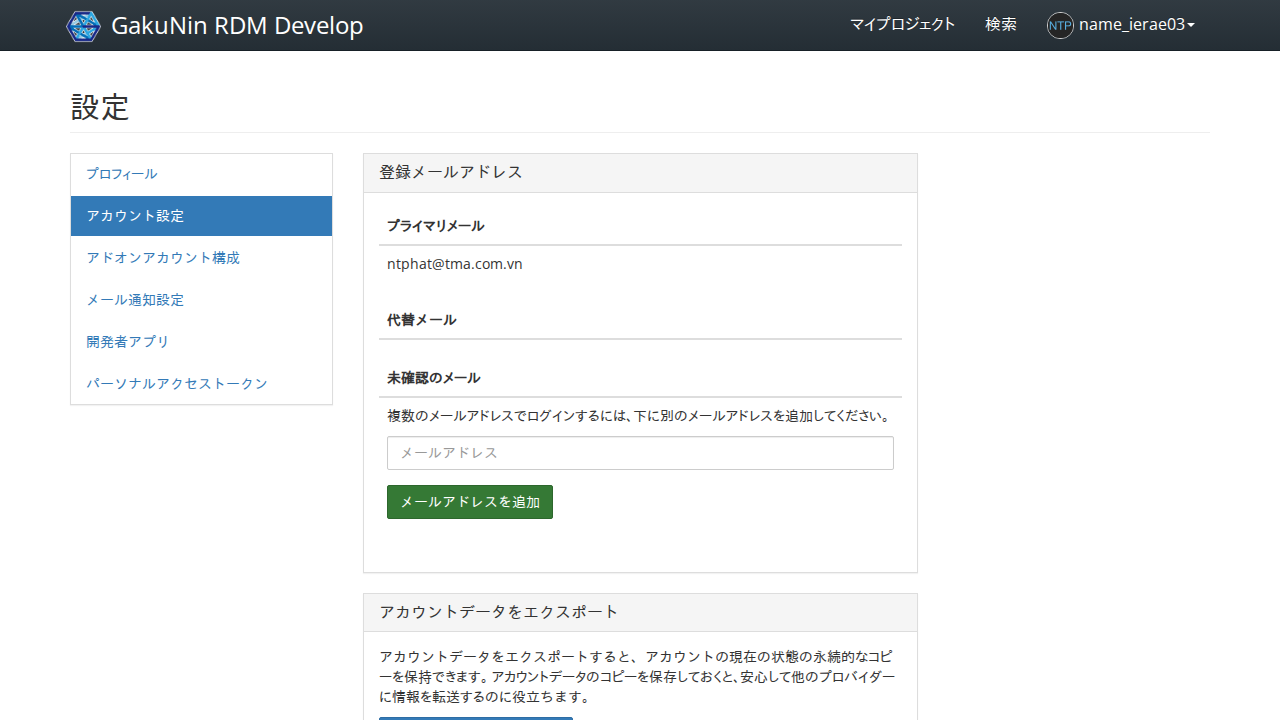

In [10]:
import os

async def _step(page):
    await page.locator('//*[text() = "アカウント設定"]').click()
    
    await expect(page.locator('[data-bind="text: profile().primaryEmail().address"]')).to_be_visible(timeout=transition_timeout)
    
    # Save primary email to a file
    primary_email = await page.locator('[data-bind="text: profile().primaryEmail().address"]').text_content()
    primary_email_file = os.path.join(default_result_path, 'primary_email.txt')

    with open(primary_email_file, 'w') as f:
        f.write(primary_email)

    print(f'Saved primary email to {primary_email_file}')

await run_pw(_step)

## ウェブブラウザの新規プライベートウィンドウで GRDM 管理者トップページを表示する

GRDM 管理者トップページが表示されること


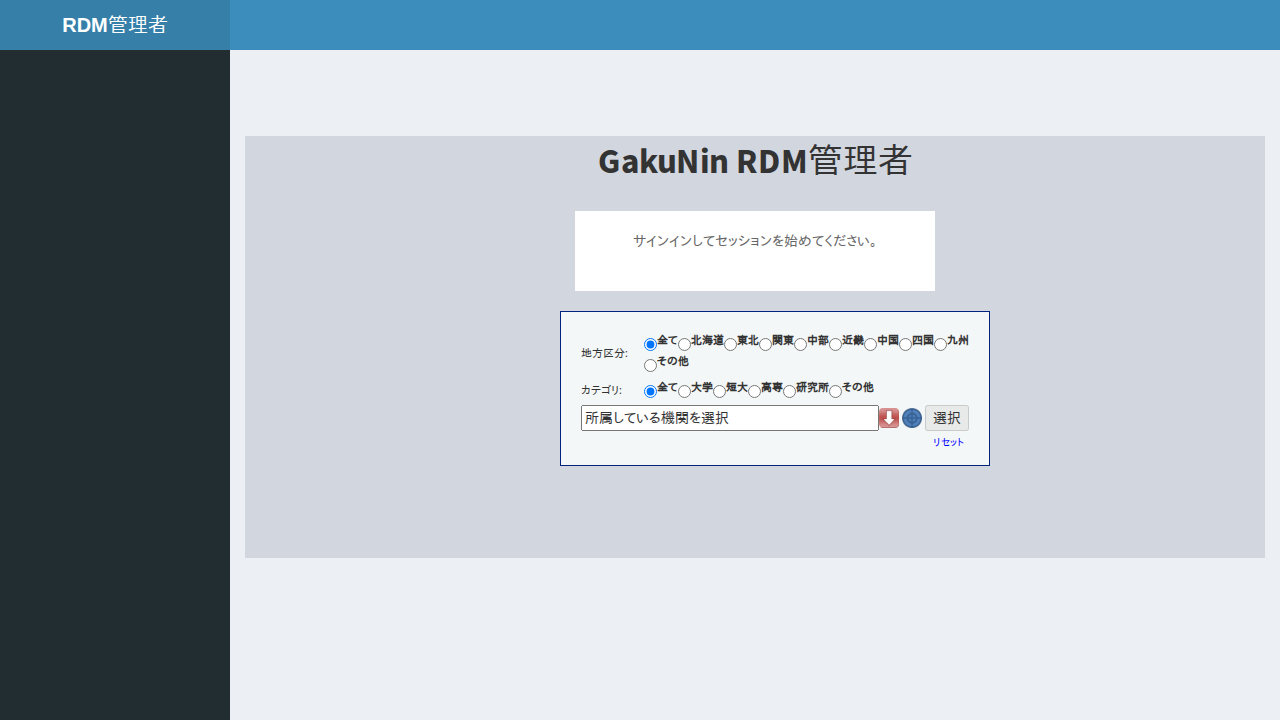

In [11]:
async def _step(page):
    await page.goto(admin_rdm_url)

    await expect(page.locator('.login-logo')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## アカウント(統合管理者既存ユーザー)を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。


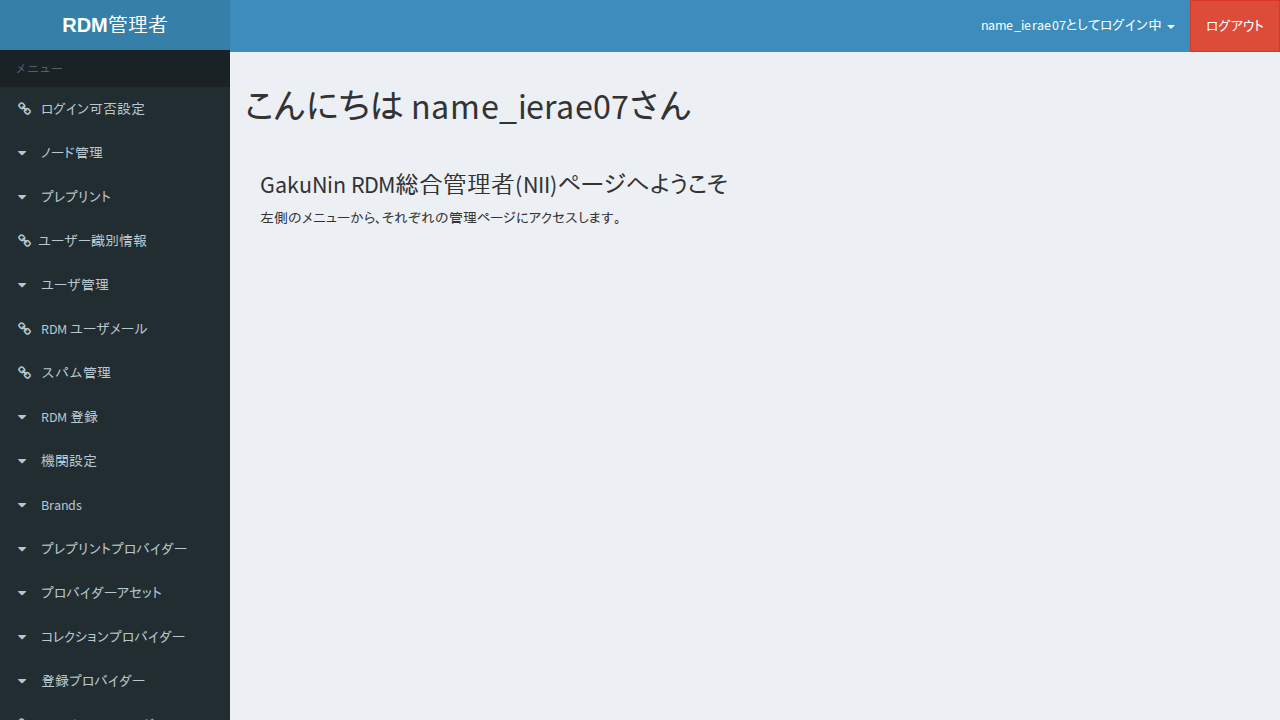

In [12]:
async def _step(page):
    await scripts.grdm.login_as_admin(
        page, idp_name_integrated_admin, idp_username_integrated_admin, idp_password_integrated_admin, transition_timeout=transition_timeout
    )

    await expect(page.locator('//*[contains(@class, "btn-danger") and contains(text(), "ログアウト")]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## メニューから「プロジェクト制限数」をクリックする

「設定テンプレート」「設定」のサブメニューが表示されること


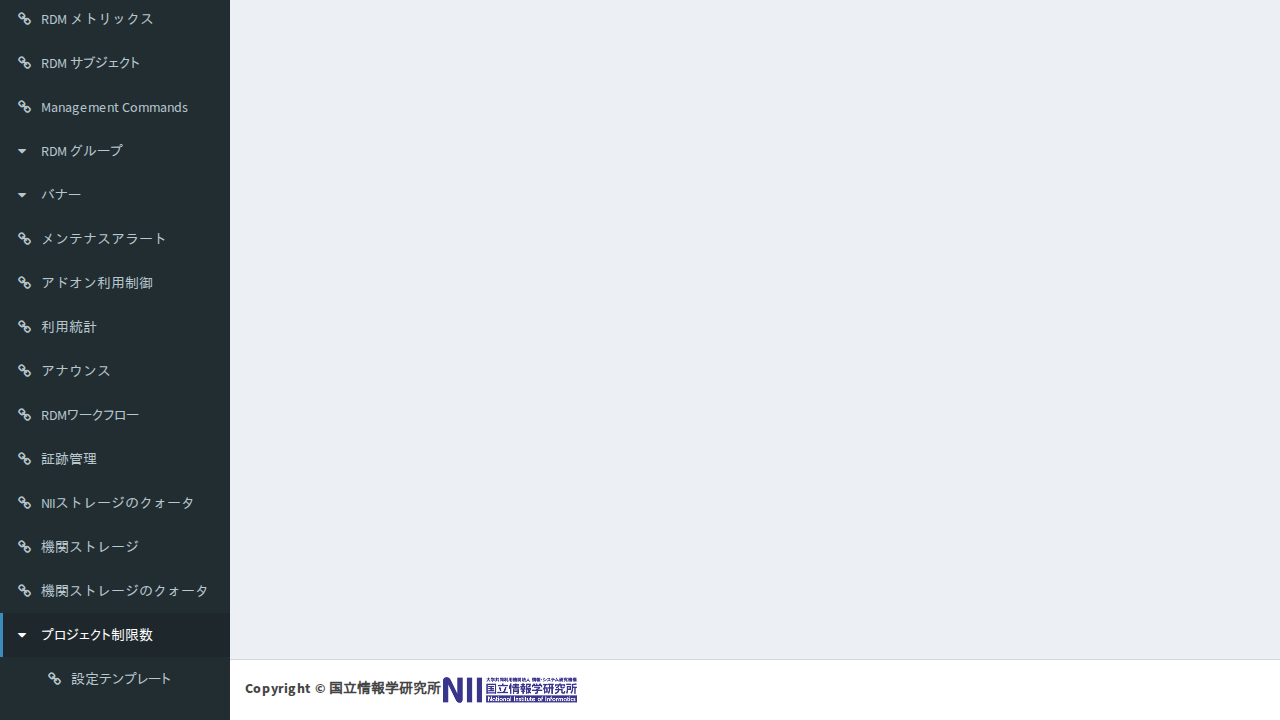

In [13]:
async def _step(page):
    await page.locator('//a[@href = "#collapseProjectLimitNumber"]').click()

    await expect(page.locator('//a[@href = "/project_limit_number/templates/"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//a[@href = "/project_limit_number/settings/"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## サブメニューから「設定テンプレート」をクリックする

・「プロジェクト作成数設定テンプレート一覧」画面が表示されること   
・「テンプレート作成・変更・削除」シートで作成した「template1」「template3」が表示されること   
・「template1」は「使用可否」のトグルボタン、「編集」ボタン、「削除ボタン」が無効になっていること   
(「ルール作成・変更・削除」シートの「setting1」「setting3」「setting4」で利用されているため)   
・「template3」は「使用可否」のトグルボタン、「編集」ボタン、「削除ボタン」が有効になっていること   


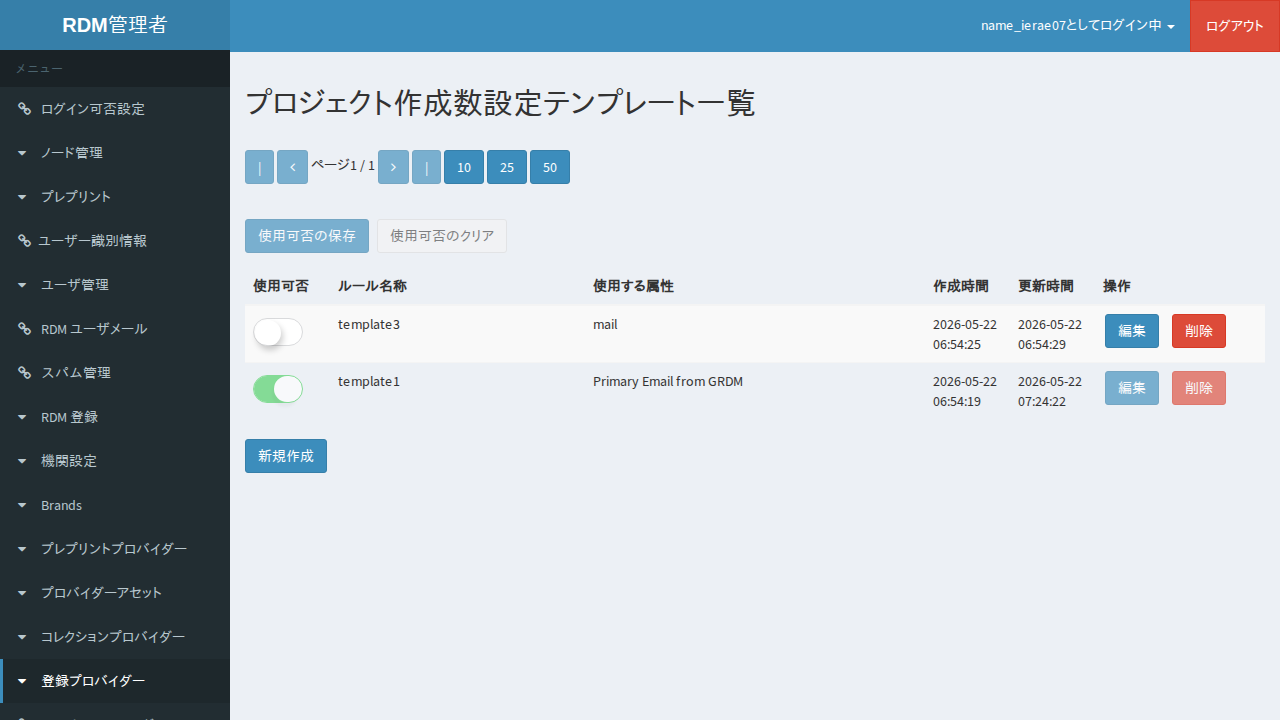

In [15]:
async def _step(page):
    await page.locator('//a[@href = "/project_limit_number/templates/"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定テンプレート一覧"]')).to_be_visible(timeout=transition_timeout)
    
    row_template1 = page.locator('#setting-template-table tbody tr').filter(has_text='template1')
    row_template3 = page.locator('#setting-template-table tbody tr').filter(has_text='template3')
    
    await expect(row_template1).to_be_visible(timeout=transition_timeout)
    await expect(row_template3).to_be_visible(timeout=transition_timeout)

    await expect(row_template1.locator('input[type="checkbox"]')).to_be_disabled(timeout=transition_timeout)
    await expect(row_template1.locator('a:has-text("編集")')).to_have_attribute('disabled', '', timeout=transition_timeout)
    await expect(row_template1.locator('button:has-text("削除")')).to_be_disabled(timeout=transition_timeout)

    await expect(row_template3.locator('input[type="checkbox"]')).to_be_enabled(timeout=transition_timeout)
    await expect(row_template3.locator('a:has-text("編集")')).not_to_have_attribute('disabled', '', timeout=transition_timeout)
    await expect(row_template3.locator('button:has-text("削除")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

終了処理を実施。

In [ ]:
await finish_pw_context()

In [ ]:
!rm -fr {work_dir}